## Setup — Catatan Ekspor TF.js

Notebook ini menyimpan model ke **3 format**: SavedModel, TFLite, dan TF.js.

Konversi TF.js memakai **environment terisolasi** (folder terpisah) agar tidak
merusak NumPy/scipy/seaborn di environment utama Kaggle. Sel setup ini **tidak
menginstal apa pun** — environment utama tetap bersih dan training berjalan
normal. Instalasi tensorflowjs terjadi otomatis (terisolasi) di sel ekspor.

Jalankan: **Run → Restart & Run All**.

In [1]:
# Setup tidak menginstal apa pun di environment utama.
# Instalasi tensorflowjs dilakukan TERISOLASI di sel ekspor (bagian akhir).
print("Setup OK. Lanjutkan Run All — environment utama tidak diubah.")

Setup OK. Lanjutkan Run All — environment utama tidak diubah.


# Klasifikasi Citra Hewan (Animal Image Classification)

**Dataset:** [Animal Image Classification Dataset (Animal Species Classification - V3)](https://www.kaggle.com/datasets/utkarshsaxenadn/animal-image-classification-dataset)

Membandingkan dua pendekatan:
1. **Model 1 — CNN From Scratch** (Sequential)
2. **Model 2 — Transfer Learning** (MobileNetV2: feature extraction + fine-tuning)

Menggunakan **5 kelas**: Panda, Monkey, Cat, Cow, Elephant.

---

## Tahap 1: Pemilihan & Persiapan Dataset

**Tema:** Hewan. Sumber Kaggle (bukan dataset yang di-ban: Rock-Paper-Scissors / Chest X-Ray).

### Struktur dataset
Dataset asli menyediakan beberapa direktori terpisah (Training, Validation, Testing) dengan gambar 256×256. Untuk proyek ini kita **menggabungkan** seluruh gambar per kelas dari ketiga folder tersebut, lalu **membaginya ulang via code** menjadi 80:10:10.

(Direktori lain — *Train Augmented*, *TFRecords*, *Interesting Data* — tidak dipakai.)

### Pembagian Data (Data Splitting) — 80 : 10 : 10
Semua gambar dari folder Training/Validation/Testing digabung per kelas, diacak, lalu dibagi ulang secara **stratified per kelas**: 80% training, 10% validation, 10% testing. Resize ke 224×224 dilakukan via code.

**Alasan memilih 80:10:10:**
- **80% training** — porsi besar agar model punya banyak contoh untuk belajar pola dengan baik.
- **10% validation** — cukup untuk memantau generalisasi dan mengatur callback (EarlyStopping, ReduceLROnPlateau) tanpa mengurangi data latih terlalu banyak.
- **10% testing** — disisihkan murni untuk evaluasi akhir pada data yang tidak pernah dilihat model.
- Karena total ribuan gambar, 10% pun masih ratusan gambar per kelas, sehingga validation & test tetap representatif secara statistik.

Pembagian ulang via code (bukan memakai folder bawaan) memberi kontrol penuh atas proporsi dan memastikan rasio tepat 80:10:10 untuk semua kelas.

In [2]:
# ============================================================
# 0. IMPORT LIBRARY
# ============================================================
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

2026-06-26 14:12:25.092803: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782483145.504469      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782483145.614839      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782483146.588353      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782483146.588398      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782483146.588401      23 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# ============================================================
# 1. DIREKTORI TRAIN / VALIDATION / TEST (hardcoded)
# ============================================================
ROOT = '/kaggle/input/datasets/utkarshsaxenadn/animal-image-classification-dataset'

TRAIN_DIR = os.path.join(ROOT, 'Training Data', 'Training Data')
VAL_DIR   = os.path.join(ROOT, 'Validation Data', 'Validation Data')
TEST_DIR  = os.path.join(ROOT, 'Testing Data', 'Testing Data')

# Verifikasi
for name, d in [('TRAIN', TRAIN_DIR), ('VAL', VAL_DIR), ('TEST', TEST_DIR)]:
    ok = os.path.isdir(d)
    subs = sorted(os.listdir(d)) if ok else []
    print(f'{name:5s}: {d}  -> {"OK" if ok else "TIDAK ADA"}, {len(subs)} kelas')

assert os.path.isdir(TRAIN_DIR) and os.path.isdir(VAL_DIR) and os.path.isdir(TEST_DIR)

TRAIN: /kaggle/input/datasets/utkarshsaxenadn/animal-image-classification-dataset/Training Data/Training Data  -> OK, 15 kelas
VAL  : /kaggle/input/datasets/utkarshsaxenadn/animal-image-classification-dataset/Validation Data/Validation Data  -> OK, 15 kelas
TEST : /kaggle/input/datasets/utkarshsaxenadn/animal-image-classification-dataset/Testing Data/Testing Data  -> OK, 15 kelas


In [4]:
# ============================================================
# 2. PILIH 5 KELAS (eksplisit)
# ============================================================
def classes_in(path):
    return set(d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d)))

common = sorted(classes_in(TRAIN_DIR) & classes_in(VAL_DIR) & classes_in(TEST_DIR))
print('Total kelas tersedia di semua split:', len(common))
print(common)

# Kelas yang dipilih untuk proyek ini:
SELECTED_CLASSES = ['Panda', 'Monkey', 'Cat', 'Cow', 'Elephant']

# pastikan semua kelas terpilih memang ada di dataset
missing = [c for c in SELECTED_CLASSES if c not in common]
assert not missing, f'Kelas tidak ditemukan di dataset: {missing}'
print('\nKelas terpilih (5):', SELECTED_CLASSES)

def count_images(path, classes):
    total = 0
    for c in classes:
        p = os.path.join(path, c)
        total += len([f for f in os.listdir(p) if f.lower().endswith(('.jpg','.jpeg','.png'))])
    return total

print('\nJumlah gambar per folder bawaan (5 kelas):')
print('  Training Data  :', count_images(TRAIN_DIR, SELECTED_CLASSES))
print('  Validation Data:', count_images(VAL_DIR, SELECTED_CLASSES))
print('  Testing Data   :', count_images(TEST_DIR, SELECTED_CLASSES))

Total kelas tersedia di semua split: 15
['Beetle', 'Butterfly', 'Cat', 'Cow', 'Dog', 'Elephant', 'Gorilla', 'Hippo', 'Lizard', 'Monkey', 'Mouse', 'Panda', 'Spider', 'Tiger', 'Zebra']

Kelas terpilih (5): ['Panda', 'Monkey', 'Cat', 'Cow', 'Elephant']

Jumlah gambar per folder bawaan (5 kelas):
  Training Data  : 10000
  Validation Data: 500
  Testing Data   : 1298


In [5]:
# ============================================================
# 3. DATA LOADER + SPLIT 80:10:10 (via code)
# ============================================================
# Dataset menyediakan folder Training/Validation/Testing terpisah.
# Untuk memenuhi ketentuan split 80:10:10, kita GABUNGKAN semua gambar
# dari ketiga folder per kelas, lalu bagi ulang secara acak (stratified
# per kelas) menjadi 80% train, 10% validation, 10% test.
#
# Alasan memilih 80:10:10:
#   - 80% training: cukup besar agar model belajar pola dengan baik.
#   - 10% validation: memantau generalisasi & callback (EarlyStopping/
#     ReduceLROnPlateau) tanpa mengurangi data latih terlalu banyak.
#   - 10% testing: evaluasi akhir pada data yang tak pernah dilihat model.
#   - Karena total ribuan gambar, 10% pun masih ratusan gambar/kelas
#     sehingga val & test tetap representatif.

import shutil

IMG_SIZE = (224, 224)
BATCH = 32
SPLIT_BASE = '/kaggle/working/data_split'   # folder hasil split

def list_images(path):
    return [os.path.join(path, f) for f in os.listdir(path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# 1) Kumpulkan SEMUA path gambar per kelas dari ketiga folder bawaan
all_by_class = {}
for c in SELECTED_CLASSES:
    paths = []
    for base in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
        d = os.path.join(base, c)
        if os.path.isdir(d):
            paths += list_images(d)
    random.shuffle(paths)
    all_by_class[c] = paths
    print(f'{c:10s}: total {len(paths)} gambar (gabungan 3 folder)')

# 2) Bagi 80:10:10 per kelas, lalu salin ke folder train/val/test
if os.path.exists(SPLIT_BASE):
    shutil.rmtree(SPLIT_BASE)
for split in ['train', 'val', 'test']:
    for c in SELECTED_CLASSES:
        os.makedirs(os.path.join(SPLIT_BASE, split, c), exist_ok=True)

for c, paths in all_by_class.items():
    n = len(paths)
    n_train = int(n * 0.80)
    n_val   = int(n * 0.10)
    parts = {
        'train': paths[:n_train],
        'val'  : paths[n_train:n_train + n_val],
        'test' : paths[n_train + n_val:],
    }
    for split, files in parts.items():
        dst_dir = os.path.join(SPLIT_BASE, split, c)
        for src in files:
            # nama unik agar tak bentrok antar folder asal
            dst = os.path.join(dst_dir, f'{abs(hash(src)) % 10**8}_{os.path.basename(src)}')
            shutil.copy(src, dst)

TRAIN_SPLIT = os.path.join(SPLIT_BASE, 'train')
VAL_SPLIT   = os.path.join(SPLIT_BASE, 'val')
TEST_SPLIT  = os.path.join(SPLIT_BASE, 'test')

# 3) Buat dataset dari folder hasil split (resize 224x224 via code)
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_SPLIT, labels='inferred', label_mode='int',
    class_names=SELECTED_CLASSES, image_size=IMG_SIZE, batch_size=BATCH,
    shuffle=True, seed=SEED)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_SPLIT, labels='inferred', label_mode='int',
    class_names=SELECTED_CLASSES, image_size=IMG_SIZE, batch_size=BATCH, shuffle=False)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_SPLIT, labels='inferred', label_mode='int',
    class_names=SELECTED_CLASSES, image_size=IMG_SIZE, batch_size=BATCH, shuffle=False)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print('\nKelas:', class_names)

# ringkasan proporsi aktual
n_tr = sum(len(os.listdir(os.path.join(TRAIN_SPLIT, c))) for c in SELECTED_CLASSES)
n_va = sum(len(os.listdir(os.path.join(VAL_SPLIT, c))) for c in SELECTED_CLASSES)
n_te = sum(len(os.listdir(os.path.join(TEST_SPLIT, c))) for c in SELECTED_CLASSES)
tot = n_tr + n_va + n_te
print(f'Split -> train {n_tr} ({n_tr/tot*100:.0f}%) | '
      f'val {n_va} ({n_va/tot*100:.0f}%) | test {n_te} ({n_te/tot*100:.0f}%)')

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Panda     : total 2337 gambar (gabungan 3 folder)
Monkey    : total 2284 gambar (gabungan 3 folder)
Cat       : total 2494 gambar (gabungan 3 folder)
Cow       : total 2277 gambar (gabungan 3 folder)
Elephant  : total 2406 gambar (gabungan 3 folder)
Found 9436 files belonging to 5 classes.


I0000 00:00:1782483266.149067      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782483266.155469      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1177 files belonging to 5 classes.
Found 1185 files belonging to 5 classes.

Kelas: ['Panda', 'Monkey', 'Cat', 'Cow', 'Elephant']
Split -> train 9436 (80%) | val 1177 (10%) | test 1185 (10%)


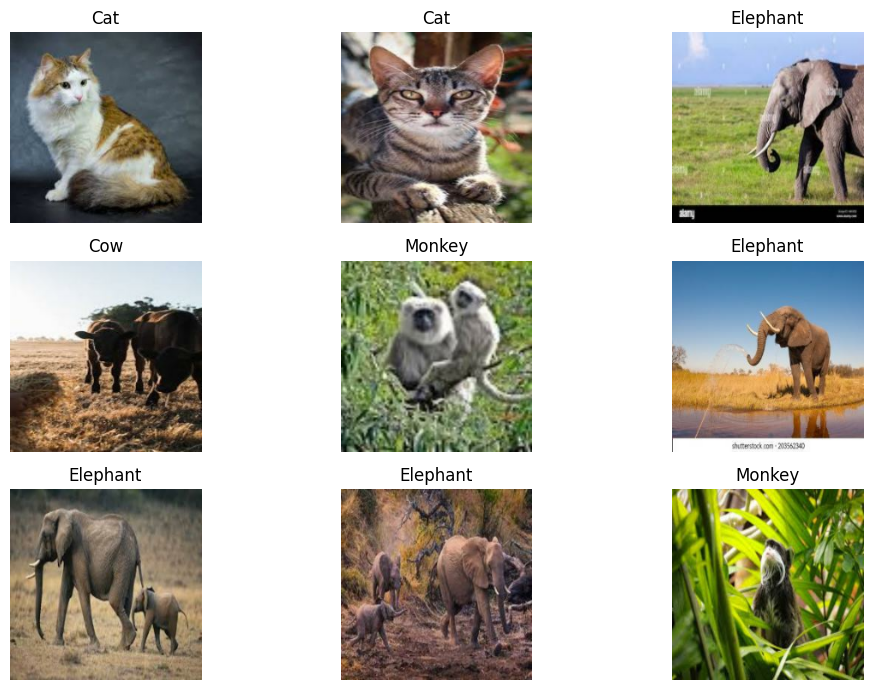

In [6]:
# ============================================================
# 4. VISUALISASI SAMPEL
# ============================================================
plt.figure(figsize=(11, 7))
for images, labels_ in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels_[i]])
        plt.axis('off')
plt.tight_layout(); plt.show()

## Tahap 2 — Model 1: CNN From Scratch (Sequential)

Wajib: `Sequential`, `Conv2D`, `MaxPooling2D`. Tambahan: `BatchNormalization`, `Dropout`, `Dense`, **Data Augmentation**, `GlobalAveragePooling2D`.

In [7]:
# ---- Data Augmentation (lebih kuat) ----
data_augmentation = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.20),
    layers.RandomZoom(0.20),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.15),
], name='data_augmentation')

# ============================================================
# MODEL 1 : CNN FROM SCRATCH (versi lebih kuat)
# - 2 Conv per blok (pola VGG-mini) + L2 weight decay
# - Dropout 0.6, augmentasi lebih kuat
# Tujuan: menutup gap train/val & menembus >88% val accuracy.
# ============================================================
L2 = regularizers.l2(1e-4)

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu', kernel_regularizer=L2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu', kernel_regularizer=L2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    return x

inp = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inp)
x = layers.Rescaling(1./255)(x)
x = conv_block(x, 32)
x = conv_block(x, 64)
x = conv_block(x, 128)
x = conv_block(x, 256)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=L2)(x)
x = layers.Dropout(0.6)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_cnn = models.Model(inp, out, name='CNN_From_Scratch_v2')
model_cnn.compile(optimizer=optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
model_cnn.summary()

Model: "CNN_From_Scratch_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,243,173 (4.74 MB)

 Trainable params: 1,241,253 (4.74 MB)

 Non-trainable params: 1,920 (7.50 KB)

### Callback & fungsinya
- **EarlyStopping** — berhenti bila `val_loss` tak membaik beberapa epoch; cegah overfitting & hemat waktu. `restore_best_weights=True` kembalikan bobot terbaik.
- **ReduceLROnPlateau** — turunkan learning rate saat metrik stagnan agar konvergensi lebih halus.
- **ModelCheckpoint** — simpan model dengan `val_accuracy` terbaik.

In [8]:
cb_cnn = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6),
    callbacks.ModelCheckpoint('best_cnn.keras', monitor='val_accuracy', save_best_only=True),
]

# Latih lebih lama; EarlyStopping menghentikan saat sudah optimal.
# TIP: untuk akurasi lebih tinggi, arahkan TRAIN_DIR ke folder
#      'Train Augmented' (10.000/kelas) di sel deteksi direktori.
EPOCHS_CNN = 60
history_cnn = model_cnn.fit(train_ds, validation_data=val_ds,
                            epochs=EPOCHS_CNN, callbacks=cb_cnn)

Epoch 1/60


I0000 00:00:1782483278.893451      74 cuda_dnn.cc:529] Loaded cuDNN version 91002


295/295 ━━━━━━━━━━━━━━━━━━━━ 97s 278ms/step - accuracy: 0.4314 - loss: 1.5428 - val_accuracy: 0.2710 - val_loss: 2.2405 - learning_rate: 0.0010
Epoch 2/60
295/295 ━━━━━━━━━━━━━━━━━━━━ 81s 275ms/step - accuracy: 0.5320 - loss: 1.2979 - val_accuracy: 0.2387 - val_loss: 3.0047 - learning_rate: 0.0010
Epoch 3/60
295/295 ━━━━━━━━━━━━━━━━━━━━ 81s 276ms/step - accuracy: 0.5818 - loss: 1.1688 - val_accuracy: 0.5242 - val_loss: 1.5576 - learning_rate: 0.0010
Epoch 4/60
295/295 ━━━━━━━━━━━━━━━━━━━━ 81s 275ms/step - accuracy: 0.6248 - loss: 1.0812 - val_accuracy: 0.4444 - val_loss: 1.7649 - learning_rate: 0.0010
Epoch 5/60
295/295 ━━━━━━━━━━━━━━━━━━━━ 81s 276ms/step - accuracy: 0.6559 - loss: 1.0084 - val_accuracy: 0.6228 - val_loss: 1.1058 - learning_rate: 0.0010
Epoch 6/60
295/295 ━━━━━━━━━━━━━━━━━━━━ 82s 277ms/step - accuracy: 0.6824 - loss: 0.9478 - val_accuracy: 0.7094 - val_loss: 0.8927 - learning_rate: 0.0010
Epoch 7/60
295/295 ━━━━━━━━━━━━━━━━━━━━ 81s 276ms/step - accuracy: 0.6939 - loss:

## Model 2: Transfer Learning — MobileNetV2

**Tahap 1 (Feature Extraction):** seluruh layer convolutional dibekukan (`weights='imagenet'`), lalu head baru: `GlobalAveragePooling2D ➔ Dense ➔ Output`.

In [9]:
# ============================================================
# MODEL 2 : TRANSFER LEARNING (MobileNetV2)
# Tahap 1 - Feature Extraction (freeze base)
# ============================================================
base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
base_model.trainable = False  # bekukan seluruh layer convolutional

inputs = layers.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = preprocess_input(x)              # preprocessing khusus MobileNetV2 (skala -1..1)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_tl = models.Model(inputs, outputs, name='MobileNetV2_TransferLearning')
model_tl.compile(optimizer=optimizers.Adam(1e-3),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
model_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
cb_tl = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    callbacks.ModelCheckpoint('best_tl.keras', monitor='val_accuracy', save_best_only=True),
]

EPOCHS_TL = 15
history_tl = model_tl.fit(train_ds, validation_data=val_ds,
                          epochs=EPOCHS_TL, callbacks=cb_tl)

Epoch 1/15
295/295 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.8774 - loss: 0.3575 - val_accuracy: 0.9720 - val_loss: 0.0814 - learning_rate: 0.0010
Epoch 2/15
295/295 ━━━━━━━━━━━━━━━━━━━━ 19s 64ms/step - accuracy: 0.9083 - loss: 0.2660 - val_accuracy: 0.9805 - val_loss: 0.0684 - learning_rate: 0.0010
Epoch 3/15
295/295 ━━━━━━━━━━━━━━━━━━━━ 18s 62ms/step - accuracy: 0.9234 - loss: 0.2285 - val_accuracy: 0.9754 - val_loss: 0.0641 - learning_rate: 0.0010
Epoch 4/15
295/295 ━━━━━━━━━━━━━━━━━━━━ 18s 62ms/step - accuracy: 0.9217 - loss: 0.2200 - val_accuracy: 0.9779 - val_loss: 0.0616 - learning_rate: 0.0010
Epoch 5/15
295/295 ━━━━━━━━━━━━━━━━━━━━ 18s 62ms/step - accuracy: 0.9237 - loss: 0.2069 - val_accuracy: 0.9788 - val_loss: 0.0581 - learning_rate: 0.0010
Epoch 6/15
295/295 ━━━━━━━━━━━━━━━━━━━━ 18s 62ms/step - accuracy: 0.9329 - loss: 0.1952 - val_accuracy: 0.9805 - val_loss: 0.0577 - learning_rate: 0.0010
Epoch 7/15
295/295 ━━━━━━━━━━━━━━━━━━━━ 18s 62ms/step - accuracy: 0.9292 - l

### Tahap 2 (Bonus) — Fine-Tuning
Buka ~30 layer terakhir base model, latih ulang dengan **learning rate jauh lebih kecil** (1e-5).

In [11]:
# ============================================================
# FINE-TUNING : buka 30 layer terakhir
# ============================================================
base_model.trainable = True
FINE_TUNE_AT = len(base_model.layers) - 30
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False
# jaga BatchNorm tetap beku agar statistik stabil
for layer in base_model.layers[FINE_TUNE_AT:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model_tl.compile(optimizer=optimizers.Adam(1e-5),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

EPOCHS_FT = 12
history_ft = model_tl.fit(train_ds, validation_data=val_ds,
                          epochs=EPOCHS_FT, callbacks=cb_tl)

Epoch 1/12
295/295 ━━━━━━━━━━━━━━━━━━━━ 28s 76ms/step - accuracy: 0.9488 - loss: 0.1510 - val_accuracy: 0.9830 - val_loss: 0.0520 - learning_rate: 1.0000e-05
Epoch 2/12
295/295 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.9500 - loss: 0.1363 - val_accuracy: 0.9805 - val_loss: 0.0471 - learning_rate: 1.0000e-05
Epoch 3/12
295/295 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.9542 - loss: 0.1304 - val_accuracy: 0.9830 - val_loss: 0.0434 - learning_rate: 1.0000e-05
Epoch 4/12
295/295 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.9572 - loss: 0.1230 - val_accuracy: 0.9839 - val_loss: 0.0437 - learning_rate: 1.0000e-05
Epoch 5/12
295/295 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.9572 - loss: 0.1176 - val_accuracy: 0.9839 - val_loss: 0.0444 - learning_rate: 1.0000e-05
Epoch 6/12
295/295 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.9646 - loss: 0.1029 - val_accuracy: 0.9830 - val_loss: 0.0464 - learning_rate: 5.0000e-06
Epoch 7/12
295/295 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/ste

In [12]:
# Gabungkan history feature-extraction + fine-tuning untuk plotting
def merge_history(h1, h2):
    out = {}
    for k in h1.history:
        out[k] = h1.history[k] + h2.history.get(k, [])
    return out

hist_tl_full = merge_history(history_tl, history_ft)

## Tahap 3 — Evaluasi & Visualisasi

### Grafik Accuracy & Loss

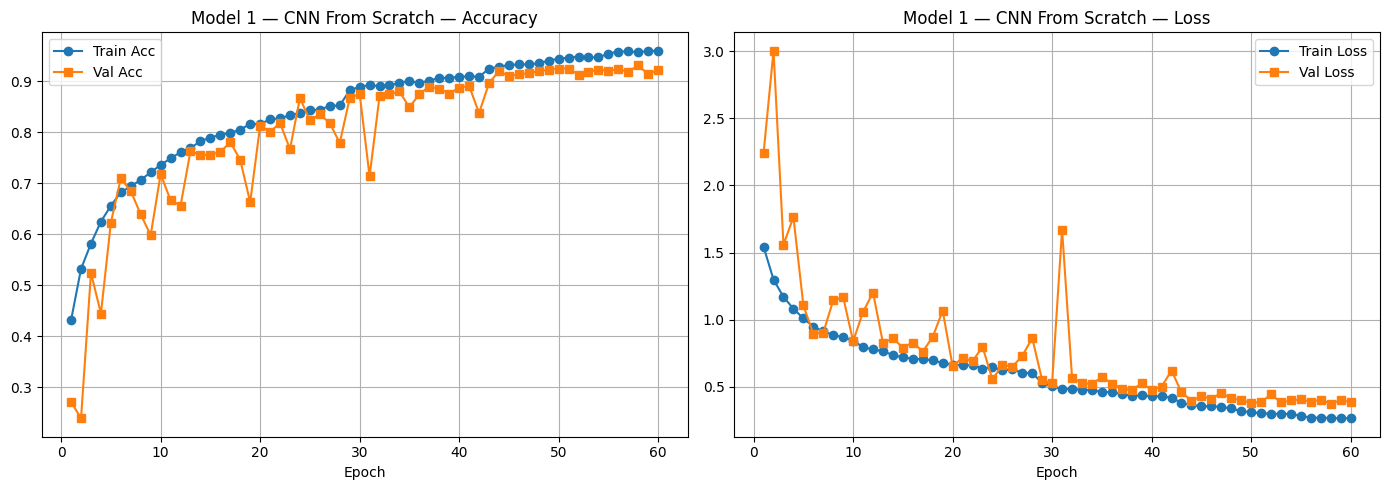

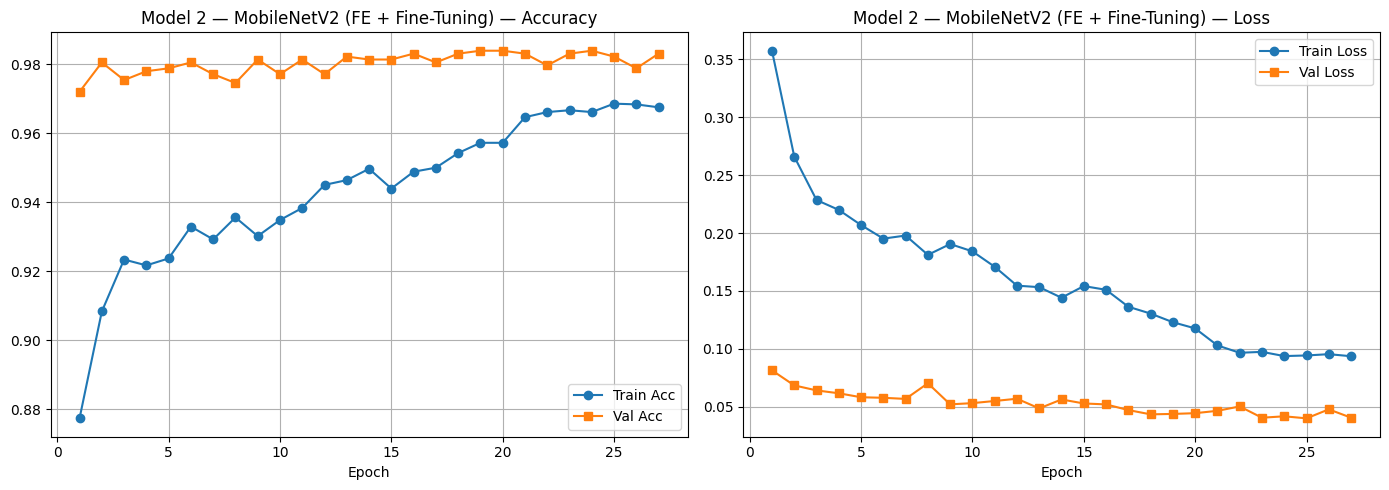

In [13]:
def plot_history(hist, title):
    acc = hist['accuracy']; val_acc = hist['val_accuracy']
    loss = hist['loss']; val_loss = hist['val_loss']
    epochs = range(1, len(acc)+1)
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].plot(epochs, acc, 'o-', label='Train Acc')
    ax[0].plot(epochs, val_acc, 's-', label='Val Acc')
    ax[0].set_title(f'{title} — Accuracy'); ax[0].set_xlabel('Epoch'); ax[0].legend(); ax[0].grid(True)
    ax[1].plot(epochs, loss, 'o-', label='Train Loss')
    ax[1].plot(epochs, val_loss, 's-', label='Val Loss')
    ax[1].set_title(f'{title} — Loss'); ax[1].set_xlabel('Epoch'); ax[1].legend(); ax[1].grid(True)
    plt.tight_layout(); plt.show()

plot_history(history_cnn.history, 'Model 1 — CNN From Scratch')
plot_history(hist_tl_full, 'Model 2 — MobileNetV2 (FE + Fine-Tuning)')

In [14]:
# ============================================================
# EVALUASI PADA TEST SET
# ============================================================
cnn_test = model_cnn.evaluate(test_ds, verbose=0)
tl_test = model_tl.evaluate(test_ds, verbose=0)
print(f'CNN From Scratch  -> Test Loss: {cnn_test[0]:.4f} | Test Acc: {cnn_test[1]*100:.2f}%')
print(f'MobileNetV2 (TL)  -> Test Loss: {tl_test[0]:.4f} | Test Acc: {tl_test[1]*100:.2f}%')

CNN From Scratch  -> Test Loss: 0.3701 | Test Acc: 91.65%
MobileNetV2 (TL)  -> Test Loss: 0.0447 | Test Acc: 98.06%


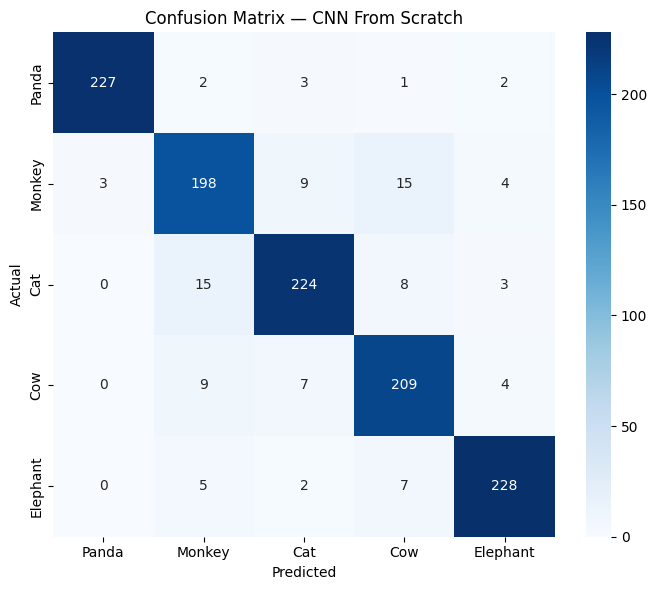


=== Classification Report — CNN From Scratch ===
              precision    recall  f1-score   support

       Panda     0.9870    0.9660    0.9763       235
      Monkey     0.8646    0.8646    0.8646       229
         Cat     0.9143    0.8960    0.9051       250
         Cow     0.8708    0.9127    0.8913       229
    Elephant     0.9461    0.9421    0.9441       242

    accuracy                         0.9165      1185
   macro avg     0.9166    0.9163    0.9163      1185
weighted avg     0.9172    0.9165    0.9167      1185



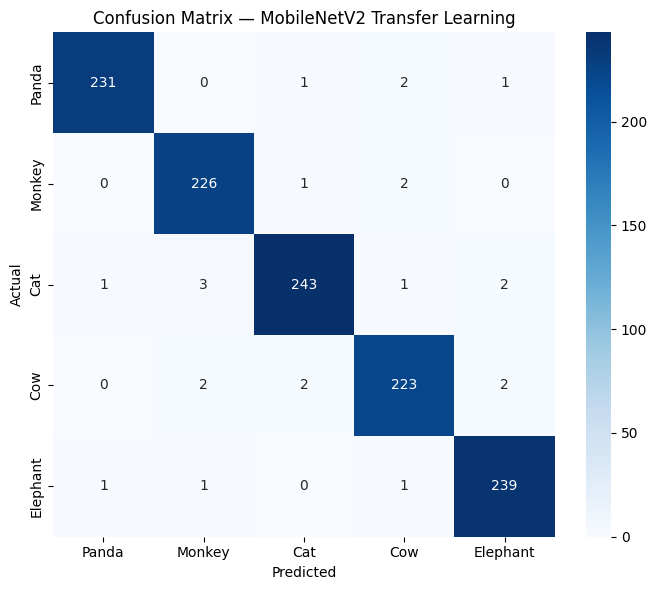


=== Classification Report — MobileNetV2 Transfer Learning ===
              precision    recall  f1-score   support

       Panda     0.9914    0.9830    0.9872       235
      Monkey     0.9741    0.9869    0.9805       229
         Cat     0.9838    0.9720    0.9779       250
         Cow     0.9738    0.9738    0.9738       229
    Elephant     0.9795    0.9876    0.9835       242

    accuracy                         0.9806      1185
   macro avg     0.9805    0.9807    0.9806      1185
weighted avg     0.9806    0.9806    0.9806      1185



In [15]:
# ============================================================
# CONFUSION MATRIX + CLASSIFICATION REPORT
# ============================================================
def evaluate_full(model, ds, title):
    y_true, y_pred = [], []
    for images, labels_ in ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels_.numpy())
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {title}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()

    print(f'\n=== Classification Report — {title} ===')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

evaluate_full(model_cnn, test_ds, 'CNN From Scratch')
evaluate_full(model_tl, test_ds, 'MobileNetV2 Transfer Learning')

## Analisis Fit (Overfitting / Underfitting / Good Fit)

Pedoman membaca grafik & angka di atas:

**Model 1 — CNN From Scratch**
- **train acc tinggi** tapi **val/test acc jauh lebih rendah** + val_loss naik → **overfitting** (perkuat augmentasi, perbesar Dropout, kurangi kapasitas).
- **train & val acc sama-sama rendah** (< target) → **underfitting** (tambah epoch/kapasitas, kurangi regularisasi).
- kurva train & val **berdekatan dan tinggi** → **good fit**.

**Model 2 — MobileNetV2 (Transfer Learning)**
- Umumnya akurasi tinggi lebih cepat. Setelah fine-tuning, train & val acc biasanya **berdekatan dan ≥ 85%** → **good fit**.
- Bila val_loss mulai naik sementara train_loss turun → awal overfitting; EarlyStopping sudah mengembalikan bobot terbaik.

**Target ≥ 85%:** Transfer Learning hampir pasti melampauinya. Jika CNN from scratch belum 85%, lakukan tuning: tambah epoch, perkuat augmentasi, ubah arsitektur, atau sesuaikan Dropout.

> Tuliskan kesimpulan akhir berdasarkan angka aktual yang diperoleh.

In [16]:
# ============================================================
# PERBANDINGAN AKHIR + PENYIMPANAN MODEL
# ============================================================
print('Ringkasan Test Accuracy:')
print(f'  Model 1 (CNN From Scratch)  : {cnn_test[1]*100:.2f}%')
print(f'  Model 2 (MobileNetV2 TL+FT) : {tl_test[1]*100:.2f}%')

model_cnn.save('model_cnn_from_scratch.keras')
model_tl.save('model_mobilenetv2_transfer.keras')
print('\nModel tersimpan: model_cnn_from_scratch.keras, model_mobilenetv2_transfer.keras')

Ringkasan Test Accuracy:
  Model 1 (CNN From Scratch)  : 91.65%
  Model 2 (MobileNetV2 TL+FT) : 98.06%

Model tersimpan: model_cnn_from_scratch.keras, model_mobilenetv2_transfer.keras


## Tahap 3 (lanjutan) — Ekspor Model ke 3 Format

Menyimpan **kedua** model (`best_cnn.keras`, `best_tl.keras`) ke:
1. **TensorFlow SavedModel** — deployment backend/cloud.
2. **TensorFlow Lite (.tflite)** — mobile/embedded.
3. **TensorFlow.js (TFJS)** — aplikasi berbasis browser.

SavedModel & TFLite memakai TensorFlow utama. TF.js dikonversi lewat
**environment terisolasi** (PYTHONPATH bersih) agar tidak merusak NumPy utama.

In [17]:
# ============================================================
# EKSPOR 3 FORMAT: SavedModel, TFLite (utama) + TF.js (terisolasi)
# ============================================================
import os, shutil, subprocess, sys

def export_savedmodel_tflite(model, name):
    base = f'exports/{name}'
    os.makedirs(base, exist_ok=True)
    sm = f'{base}/savedmodel'
    if os.path.exists(sm): shutil.rmtree(sm)
    try:
        model.export(sm)                 # Keras 3
    except AttributeError:
        tf.saved_model.save(model, sm)   # fallback
    print(f'  SavedModel -> {sm}')
    conv = tf.lite.TFLiteConverter.from_keras_model(model)
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS,
                                      tf.lite.OpsSet.SELECT_TF_OPS]
    tfl = conv.convert()
    with open(f'{base}/model.tflite','wb') as f:
        f.write(tfl)
    sz = os.path.getsize(base+'/model.tflite')/1e6
    print(f'  TFLite     -> {base}/model.tflite ({sz:.1f} MB)')

best_cnn = tf.keras.models.load_model('best_cnn.keras', compile=False)
best_tl  = tf.keras.models.load_model('best_tl.keras',  compile=False)

print('=== SavedModel + TFLite ===')
print('[CNN]'); export_savedmodel_tflite(best_cnn, 'cnn')
print('[TL ]'); export_savedmodel_tflite(best_tl,  'tl')

# ---------- TF.js terisolasi ----------
print('\n=== TF.js (instalasi terisolasi) ===')
TFJS_DIR    = '/kaggle/working/_tfjs_env'
SCRIPT_PATH = '/kaggle/working/_run_tfjs.py'

if not (os.path.isdir(TFJS_DIR) and os.listdir(TFJS_DIR)):
    os.makedirs(TFJS_DIR, exist_ok=True)
    print('  Menginstal tensorflowjs terisolasi (beberapa menit)...')
    r = subprocess.run([sys.executable,'-m','pip','install','-q',
                        '--target',TFJS_DIR,'tensorflowjs'],
                       capture_output=True,text=True)
    print('  install rc:', r.returncode)
    if r.returncode != 0:
        print(r.stderr[-1500:])
else:
    print('  (env terisolasi sudah ada)')

# Tulis skrip konverter (dijalankan dgn PYTHONPATH BERSIH = hanya folder terisolasi)
_script = (
    'import sys, os\n'
    'sys.path.insert(0, os.environ["TFJS_TARGET"])\n'
    'from tensorflowjs.converters import converter\n'
    'src, out = sys.argv[1], sys.argv[2]\n'
    'converter.convert(["--input_format=keras", src, out])\n'
)
with open(SCRIPT_PATH,'w') as f:
    f.write(_script)

def convert_keras(keras_path, out_dir):
    if os.path.exists(out_dir): shutil.rmtree(out_dir)
    os.makedirs(out_dir, exist_ok=True)
    env = dict(os.environ)
    env['TFJS_TARGET'] = TFJS_DIR
    env['PYTHONPATH']  = TFJS_DIR
    r = subprocess.run([sys.executable, SCRIPT_PATH, keras_path, out_dir],
                       capture_output=True, text=True, env=env)
    if r.returncode != 0:
        print('    [TFJS error]', (r.stderr or r.stdout)[-1600:])
        return False
    return True

if os.path.isdir(TFJS_DIR) and os.listdir(TFJS_DIR):
    for nm, kp in [('cnn','best_cnn.keras'), ('tl','best_tl.keras')]:
        ok = convert_keras(kp, f'exports/{nm}/tfjs')
        print(f'  [{nm}] TF.js ->', f'exports/{nm}/tfjs' if ok else '[GAGAL]')
else:
    print('  [SKIP] tensorflowjs tak terpasang — SavedModel & TFLite tetap ada.')

print('\nStruktur folder exports/:')
for root, dirs, files in os.walk('exports'):
    lvl = root.count(os.sep) - 1
    print('  ' * lvl, os.path.basename(root) + '/')
    for f in sorted(files):
        print('  ' * (lvl+1), f)

=== SavedModel + TFLite ===
[CNN]
INFO:tensorflow:Assets written to: exports/cnn/savedmodel/assets


INFO:tensorflow:Assets written to: exports/cnn/savedmodel/assets


Saved artifact at 'exports/cnn/savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132513314223312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513314219664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513314222544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513314223504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513314219856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513314220624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513314221008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513314222928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513314223888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513314217360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513314

INFO:tensorflow:Assets written to: /tmp/tmpp6w4069p/assets


Saved artifact at '/tmp/tmpp6w4069p'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132513314220624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513314221008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513314222928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513314223888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513314217360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513314217168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513314220240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513314217936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513314223696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513314225232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513314225040

...

Saved artifact at 'exports/tl/savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132513351573072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513351571152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513351573264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513351572880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513351569808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513351573456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513351574224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513351574032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513351573648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513351574800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13251335

INFO:tensorflow:Assets written to: /tmp/tmpqffj3cup/assets


Saved artifact at '/tmp/tmpqffj3cup'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132513351573456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513351574224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513351574032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513351573648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513351574800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513351568464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513351574416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513351574608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513351569232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132513351575760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1325133515751

W0000 00:00:1782488769.138694      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1782488769.138718      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


  TFLite     -> exports/tl/model.tflite (2.7 MB)

=== TF.js (instalasi terisolasi) ===
  Menginstal tensorflowjs terisolasi (beberapa menit)...
  install rc: 0
    [TFJS error] sts.component.inspector import inspector as inspector_lib
  File "/kaggle/working/_tfjs_env/tensorflow_decision_forests/component/inspector/inspector.py", line 64, in <module>
    from tensorflow_decision_forests.component import py_tree
  File "/kaggle/working/_tfjs_env/tensorflow_decision_forests/component/py_tree/__init__.py", line 20, in <module>
    from tensorflow_decision_forests.component.py_tree import condition
  File "/kaggle/working/_tfjs_env/tensorflow_decision_forests/component/py_tree/condition.py", line 26, in <module>
    from tensorflow_decision_forests.component.py_tree import dataspec as dataspec_lib
  File "/kaggle/working/_tfjs_env/tensorflow_decision_forests/component/py_tree/dataspec.py", line 24, in <module>
    from yggdrasil_decision_forests.dataset import data_spec_pb2
  File "/kaggle